# 029 — New System-Prompt Drift (HiddenBench)

Compares the **old** system-prompt runs (`results/mas/final_dataset`, HiddenBench only)
against the **new, more critical** system-prompt runs (`results/mas/final_dataset_new_system`)
on the **same 35 HiddenBench questions × 6 configs** (W∈{1,2,5} × {fc,star}).

**The prompt change (dataset-wide, verified in all 210 new vs 0 old files).** The new persona
appends one explicit anti-conformity instruction:

> *Be critical — your neighbors may be wrong, and so may you. **Do not change your position
> simply because others disagree; only update if you encounter a specific argument you cannot
> counter.***

(The old persona ends at "…and so may you." A trivial Phase-A wording trim — "or number" removed —
also differs.)

**Known confounds, reported as-is (no data modification):**

1. **Repetitions differ.** Old = R30 (downsampled), new = R50. We compare at the paired-task level,
   so the different rep counts only affect the precision of each task's estimate, not the pairing.
2. **Confidence scale.** The prompt defines confidence as an integer **1–10** (`agent.py:74`); the
   new data uses the full 1–10 range (1 and 2 are rare but present — purely prompt-driven, not
   clamped). The **old** data contains stray **0-confidence** values (a known artifact). Confidence
   enters only the *confidence-weighted* metrics (dominance credit, self-reinforcement slopes); we
   flag this where relevant but do **not** alter either dataset.
3. **No GPQA in the new run** → this analysis is HiddenBench-only.

**Statistics.** The paired unit is the shared **question id (qid)**, paired **within each config**.
For every metric we aggregate to one value per (config, qid) for each dataset, then run a
**Wilcoxon signed-rank** test on the 35 paired deltas per config, **Holm-corrected across the 6
configs**, and report a **bootstrap 95% CI on the mean paired delta**. Aggregating to the task level
before testing avoids rep-level pseudoreplication (reps within a task share the same question).


In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.dominance import analyse_dominance
from src.metrics.self_reinforcement import extract_runs, summarise_runs
from src.metrics.limit_cycles import detect_agent_limit_cycles, detect_system_limit_cycles
from src.metrics.bistability import analyse_bistability

OLD_BASE = Path('..') / 'results' / 'mas' / 'final_dataset'
NEW_BASE = Path('..') / 'results' / 'mas' / 'final_dataset_new_system'

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
CONFIG_ORDER = [f'{t}/W={w}' for t in TOPOS for w in W_VALUES]
DS_ORDER = ['old', 'new']
DS_LABEL = {'old': 'Old prompt', 'new': 'New prompt'}
DS_COLOR = {'old': '#7f7f7f', 'new': '#EE6666'}
T_CEIL   = 15
SEED     = 42
B_DOM    = 1000   # surrogate draws for dominance (matches nb 022)
B_LC     = 1000   # shuffle surrogates for limit cycles
B_BIST   = 1000   # permutation draws for bistability basin test

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
np.set_printoptions(suppress=True)
print('setup ok')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


setup ok


In [2]:
def iter_files(base):
    for f in sorted(base.glob('**/*.json')):
        if 'hiddenbench' not in f.name:
            continue
        yield f

def load_meta(base, ds_tag):
    rows = []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        reps = d['repetitions']
        rounds = [len(r['trajectory']) - 1 for r in reps]
        confs = [pb.get('confidence') for r in reps
                 for rd in r['trajectory'] for pb in rd['phase_b']]
        confs = [c for c in confs if c is not None]
        rows.append({
            'ds': ds_tag,
            'W': d['W'],
            'topology': d.get('topology_name', 'fc'),
            'config': d.get('topology_name', 'fc') + '/W=' + str(d['W']),
            'qid': d['question_id'],
            'M': len(d['options']),
            'n_reps': len(reps),
            'mean_rounds': float(np.mean(rounds)),
            'conf_min': int(min(confs)),
            'conf_max': int(max(confs)),
            'n_conf_zero': int(sum(c == 0 for c in confs)),
        })
    return pd.DataFrame(rows)

meta = pd.concat([load_meta(OLD_BASE, 'old'), load_meta(NEW_BASE, 'new')], ignore_index=True)
print(f'files: old={ (meta.ds=="old").sum() }  new={ (meta.ds=="new").sum() }')
print()
print('per-dataset provenance:')
prov = meta.groupby('ds').agg(
    files=('qid', 'size'),
    n_reps_mean=('n_reps', 'mean'),
    conf_min=('conf_min', 'min'),
    conf_max=('conf_max', 'max'),
    n_conf_zero=('n_conf_zero', 'sum'),
).round(2)
print(prov.to_string())

files: old=210  new=210

per-dataset provenance:
     files  n_reps_mean  conf_min  conf_max  n_conf_zero
ds                                                      
new    210         50.0         1        10            0
old    210         30.0         0        10         1183


In [3]:
# --- assert the two datasets are a clean paired design -------------------
old_keys = set(map(tuple, meta[meta.ds=='old'][['config','qid']].values))
new_keys = set(map(tuple, meta[meta.ds=='new'][['config','qid']].values))
assert old_keys == new_keys, f'unpaired cells: old-only={old_keys-new_keys}, new-only={new_keys-old_keys}'
n_qids = meta[meta.ds=='new']['qid'].nunique()
print(f'PAIRED design confirmed: {len(new_keys)} (config,qid) cells, {n_qids} qids x {len(CONFIG_ORDER)} configs.')
print('shared qids:', sorted(meta[meta.ds=="new"].qid.unique()))

# stray out-of-option votes (data-quality drift signal): known transient 'D' artifact
def scan_stray(base):
    n_cells = n_rounds = n_votes = 0
    for f in iter_files(base):
        d = json.loads(f.read_text()); opts = set(d['options'].keys()); hit = False
        for rep in d['repetitions']:
            for rd in rep['trajectory']:
                extra = [pb['vote'] for pb in rd['phase_b'] if pb['vote'] not in opts]
                if extra:
                    n_rounds += 1; n_votes += len(extra); hit = True
        n_cells += hit
    return n_cells, n_rounds, n_votes
print()
print('stray out-of-option votes (cells, rounds, votes):')
print('  old:', scan_stray(OLD_BASE), '  new:', scan_stray(NEW_BASE))

PAIRED design confirmed: 210 (config,qid) cells, 35 qids x 6 configs.
shared qids: ['1', '10', '11', '13', '14', '15', '16', '18', '2', '20', '22', '24', '25', '28', '31', '34', '35', '37', '40', '41', '42', '43', '44', '45', '46', '48', '51', '52', '56', '57', '58', '6', '64', '8', '9']

stray out-of-option votes (cells, rounds, votes):


  old: (1, 1, 1)   new: (0, 0, 0)


### Paired-test helpers

`paired_wilcoxon` takes a long dataframe with columns `[config, qid, ds, <value>]`, pivots to
old/new per (config, qid), drops unpaired/NaN pairs, and for each config returns the paired mean
delta (new − old), a bootstrap 95% CI on that delta, the Wilcoxon signed-rank p, and n pairs.
p-values are **Holm-corrected across the 6 configs**. `direction` reads the sign of the median delta.


In [4]:
def _boot_ci(delta, B=5000, seed=SEED):
    d = np.asarray(delta, float)
    d = d[~np.isnan(d)]
    if len(d) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = d[rng.integers(0, len(d), size=(B, len(d)))].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

def _holm(pvals):
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    m = len(p)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        val = (m - rank) * p[idx]
        running = max(running, val)
        adj[idx] = min(running, 1.0)
    return adj

def paired_wilcoxon(df_long, value, configs=CONFIG_ORDER):
    rows = []
    for cfg in configs:
        sub = df_long[df_long.config == cfg]
        piv = sub.pivot_table(index='qid', columns='ds', values=value, aggfunc='mean')
        piv = piv.dropna(subset=['old', 'new'])
        old_v, new_v = piv['old'].values, piv['new'].values
        delta = new_v - old_v
        n = len(delta)
        mean_delta = float(np.mean(delta)) if n else np.nan
        lo, hi = _boot_ci(delta)
        if n >= 1 and np.any(delta != 0):
            try:
                stat, p = sp_stats.wilcoxon(new_v, old_v, zero_method='wilcox')
            except ValueError:
                p = np.nan
        else:
            p = np.nan
        rows.append({
            'config': cfg, 'n_pairs': n,
            'old_mean': float(np.mean(old_v)) if n else np.nan,
            'new_mean': float(np.mean(new_v)) if n else np.nan,
            'delta': mean_delta, 'ci_lo': lo, 'ci_hi': hi,
            'p_raw': p,
        })
    out = pd.DataFrame(rows)
    out['p_holm'] = _holm(out['p_raw'].fillna(1.0).values)
    out['sig'] = out['p_holm'].apply(lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns')
    return out

def show(res, title, fmt='{:+.4f}'):
    print(f'=== {title} — paired new vs old, Wilcoxon (Holm across configs) ===')
    disp = res.copy()
    for c in ['old_mean', 'new_mean', 'delta', 'ci_lo', 'ci_hi']:
        disp[c] = disp[c].map(lambda x: fmt.format(x) if pd.notna(x) else 'nan')
    disp['p_holm'] = disp['p_holm'].map(lambda x: f'{x:.3g}')
    print(disp[['config','n_pairs','old_mean','new_mean','delta','ci_lo','ci_hi','p_holm','sig']].to_string(index=False))
print('helpers ok')

helpers ok


## 1. Accuracy & efficiency

Task-level values per (config, qid): **accuracy** = mean of `rep['correct']`; **mean_rounds** =
mean trajectory length − 1 (rounds to consensus); **ceil_frac** = fraction of reps hitting the
T=15 ceiling (where high, mean_rounds is a lower bound).


In [5]:
def load_taskvals(base, ds_tag):
    rows = []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        reps = d['repetitions']
        rounds = np.array([len(r['trajectory']) - 1 for r in reps])
        rows.append({
            'ds': ds_tag,
            'config': d.get('topology_name','fc') + '/W=' + str(d['W']),
            'topology': d.get('topology_name','fc'),
            'W': d['W'], 'qid': d['question_id'],
            'accuracy': float(np.mean([r['correct'] for r in reps])),
            'mean_rounds': float(rounds.mean()),
            'ceil_frac': float(np.mean(rounds >= T_CEIL)),
        })
    return pd.DataFrame(rows)

taskvals = pd.concat([load_taskvals(OLD_BASE,'old'), load_taskvals(NEW_BASE,'new')], ignore_index=True)
print('overall (pooled across configs):')
print(taskvals.groupby('ds')[['accuracy','mean_rounds','ceil_frac']].mean().round(4).to_string())

overall (pooled across configs):
     accuracy  mean_rounds  ceil_frac
ds                                   
new    0.2940       6.0402     0.0730
old    0.3163       6.8517     0.1462


In [6]:
acc_res = paired_wilcoxon(taskvals, 'accuracy')
show(acc_res, 'Accuracy')

=== Accuracy — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       35  +0.2990  +0.2880 -0.0110 -0.0613 +0.0394      1  ns
  fc/W=2       35  +0.3210  +0.3206 -0.0004 -0.0625 +0.0636      1  ns
  fc/W=5       35  +0.3210  +0.2971 -0.0238 -0.0874 +0.0398      1  ns
star/W=1       35  +0.3038  +0.2777 -0.0261 -0.0724 +0.0164      1  ns
star/W=2       35  +0.3248  +0.2943 -0.0305 -0.0836 +0.0217      1  ns
star/W=5       35  +0.3286  +0.2863 -0.0423 -0.1015 +0.0131      1  ns


In [7]:
rnd_res = paired_wilcoxon(taskvals, 'mean_rounds')
show(rnd_res, 'Mean rounds-to-consensus', fmt='{:+.3f}')
print()
ceil_res = paired_wilcoxon(taskvals, 'ceil_frac')
show(ceil_res, 'Ceiling-hit fraction (reps reaching T=15)')

=== Mean rounds-to-consensus — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean  delta  ci_lo  ci_hi   p_holm sig
  fc/W=1       35   +6.486   +5.467 -1.018 -1.723 -0.457  0.00514  **
  fc/W=2       35   +6.004   +4.908 -1.096 -1.805 -0.472   0.0289   *
  fc/W=5       35   +6.470   +4.988 -1.482 -2.178 -0.866 7.13e-05 ***
star/W=1       35   +7.784   +7.559 -0.224 -0.757 +0.273        1  ns
star/W=2       35   +7.147   +6.782 -0.364 -0.921 +0.156        1  ns
star/W=5       35   +7.220   +6.536 -0.684 -1.203 -0.200   0.0794  ns

=== Ceiling-hit fraction (reps reaching T=15) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi   p_holm sig
  fc/W=1       35  +0.1124  +0.0326 -0.0798 -0.1392 -0.0349 0.000748 ***
  fc/W=2       35  +0.1057  +0.0120 -0.0937 -0.1484 -0.0465 0.000618 ***
  fc/W=5       35  +0.1457  +0.0211 -0.1246 -0.1819 -0.0739 5.28e-05 ***
star/W=1       35  +0.1638  +0

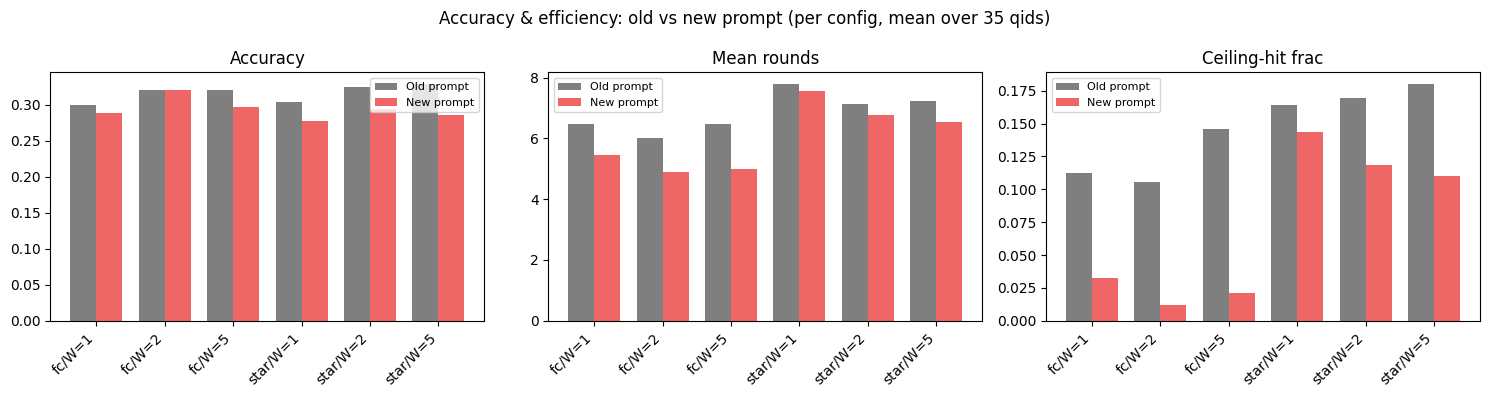

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, ttl) in zip(axes, [('accuracy','Accuracy'),('mean_rounds','Mean rounds'),('ceil_frac','Ceiling-hit frac')]):
    piv = taskvals.pivot_table(index=['config','qid'], columns='ds', values=col).dropna()
    x = np.arange(len(CONFIG_ORDER)); w = 0.38
    for k, ds in enumerate(DS_ORDER):
        means = [taskvals[(taskvals.ds==ds)&(taskvals.config==c)][col].mean() for c in CONFIG_ORDER]
        ax.bar(x + (k-0.5)*w, means, w, label=DS_LABEL[ds], color=DS_COLOR[ds])
    ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, rotation=45, ha='right')
    ax.set_title(ttl); ax.legend(fontsize=8)
fig.suptitle('Accuracy & efficiency: old vs new prompt (per config, mean over 35 qids)')
plt.tight_layout(); plt.show()

## 2. Dominance

Per-rep influence-concentration `D` (Herfindahl of confidence-weighted influence shares) via
`analyse_dominance` (B=1000 surrogates, Theiler-0 null). Task-level value = mean `D` over reps in a
cell. `z_mean` / `flagged_fraction` (emergent excess concentration vs the topology null) are
**identifiable in fc only** — the star null is a point mass for >80% of reps by construction (nb 022)
— so we report z/flag for **fc configs only**.

**Confidence caveat:** `D` is confidence-weighted. The old data's stray 0-confidence votes contribute
zero credit; the new data has no zeros. Direction/magnitude shifts here partly reflect that
difference, not only the prompt. `D` is invariant to positive rescaling, so this affects only the
zero-weight votes, not the 1–10 spread.


In [9]:
def load_dominance(base, ds_tag):
    rep_rows, cell_rows = [], []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        reps = d['repetitions']
        cfg = d.get('topology_name','fc') + '/W=' + str(d['W'])
        topo = d.get('topology_name','fc')
        res = [analyse_dominance(rep, B=B_DOM, seed=SEED) for rep in reps]
        valid = [r for r in res if r is not None]
        testable = [r for r in valid if r['testable']]
        Ds = [r['D'] for r in valid]
        zs = [r['z'] for r in testable]
        flags = [r['flagged'] for r in testable]
        caps = [r['hub_capitulation'] for r in valid]
        cell_rows.append({
            'ds': ds_tag, 'config': cfg, 'topology': topo, 'W': d['W'], 'qid': d['question_id'],
            'D_mean': float(np.mean(Ds)) if Ds else np.nan,
            'z_mean': float(np.mean(zs)) if zs else np.nan,
            'flagged_fraction': float(np.mean(flags)) if flags else np.nan,
            'hub_capitulation': float(np.mean(caps)) if caps else np.nan,
            'n_valid': len(valid), 'n_testable': len(testable),
        })
    return pd.DataFrame(cell_rows)

print('computing dominance (B=%d) ... this is the slow step (~10 min total)' % B_DOM)
dom = pd.concat([load_dominance(OLD_BASE,'old'), load_dominance(NEW_BASE,'new')], ignore_index=True)
print('done. overall D_mean by ds:')
print(dom.groupby('ds')[['D_mean','hub_capitulation']].mean().round(4).to_string())

computing dominance (B=1000) ... this is the slow step (~10 min total)


done. overall D_mean by ds:
     D_mean  hub_capitulation
ds                           
new  0.3628            0.1685
old  0.3753            0.1463


In [10]:
dom_res = paired_wilcoxon(dom, 'D_mean')
show(dom_res, 'Dominance D (mean per cell)')
print()
cap_res = paired_wilcoxon(dom, 'hub_capitulation')
show(cap_res, 'Hub capitulation (confidence-weighted)')

=== Dominance D (mean per cell) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       35  +0.1716  +0.1577 -0.0139 -0.0421 +0.0087      1  ns
  fc/W=2       35  +0.1935  +0.1800 -0.0135 -0.0357 +0.0069      1  ns
  fc/W=5       35  +0.1878  +0.1773 -0.0104 -0.0339 +0.0097      1  ns
star/W=1       35  +0.5144  +0.5318 +0.0173 -0.0110 +0.0472      1  ns
star/W=2       35  +0.5951  +0.5645 -0.0306 -0.0645 +0.0016  0.712  ns
star/W=5       35  +0.5891  +0.5653 -0.0238 -0.0566 +0.0099  0.712  ns

=== Hub capitulation (confidence-weighted) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi  p_holm sig
  fc/W=1       35  +0.1133  +0.1373 +0.0241 +0.0105 +0.0369 0.00183  **
  fc/W=2       35  +0.1189  +0.1398 +0.0209 +0.0083 +0.0339  0.0181   *
  fc/W=5       35  +0.1164  +0.1341 +0.0177 +0.0041 +0.0323  0.0841  ns
star/W=1       35  +0.1741 

In [11]:
fc_dom = dom[dom.topology=='fc']
zres = paired_wilcoxon(fc_dom, 'z_mean', configs=[c for c in CONFIG_ORDER if c.startswith('fc')])
show(zres, 'Emergent excess z (fc only)', fmt='{:+.3f}')
print()
fres = paired_wilcoxon(fc_dom, 'flagged_fraction', configs=[c for c in CONFIG_ORDER if c.startswith('fc')])
show(fres, 'Flagged fraction — reps with significant emergent concentration (fc only)')

=== Emergent excess z (fc only) — paired new vs old, Wilcoxon (Holm across configs) ===
config  n_pairs old_mean new_mean  delta  ci_lo  ci_hi p_holm sig
fc/W=1       35   +0.534   +0.635 +0.102 -0.025 +0.236  0.326  ns
fc/W=2       35   +0.653   +0.835 +0.182 +0.039 +0.327  0.069  ns
fc/W=5       35   +0.629   +0.792 +0.163 +0.001 +0.324 0.0743  ns

=== Flagged fraction — reps with significant emergent concentration (fc only) — paired new vs old, Wilcoxon (Holm across configs) ===
config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
fc/W=1       35  +0.0923  +0.1083 +0.0160 -0.0156 +0.0481  0.688  ns
fc/W=2       35  +0.0998  +0.1168 +0.0171 -0.0065 +0.0380  0.272  ns
fc/W=5       35  +0.0875  +0.1144 +0.0269 -0.0007 +0.0551  0.272  ns


## 3. Self-reinforcement

Over vote-stable runs (length ≥ 3), the OLS slope of confidence vs round (`extract_runs` /
`summarise_runs`). `p_sr` = fraction of runs with slope > 0 (baseline 0.5 = no self-reinforcement);
`mean_slope` = mean confidence gain per round while holding a position. Task-level value = summarise
over the cell's runs.

**Confidence caveat:** slopes are computed on the raw confidence integers. Old-data 0-values sit
below the 1–10 range and can inflate/deflate individual slopes; interpret cross-dataset slope
*magnitude* cautiously. `p_sr` (sign only) is more robust to the scale artifact.


In [12]:
def load_selfreinf(base, ds_tag):
    rows = []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        s = summarise_runs(extract_runs(d['repetitions']))
        rows.append({
            'ds': ds_tag,
            'config': d.get('topology_name','fc') + '/W=' + str(d['W']),
            'qid': d['question_id'],
            'p_sr': s['p_sr'], 'mean_slope': s['mean_slope'],
            'p_sr_terminal': s['p_sr_terminal'], 'n_runs': s['n_runs'],
        })
    return pd.DataFrame(rows)

sr = pd.concat([load_selfreinf(OLD_BASE,'old'), load_selfreinf(NEW_BASE,'new')], ignore_index=True)
print('overall by ds:')
print(sr.groupby('ds')[['p_sr','mean_slope','p_sr_terminal','n_runs']].mean().round(4).to_string())

overall by ds:
       p_sr  mean_slope  p_sr_terminal    n_runs
ds                                              
new  0.8323      0.3920         0.8560  234.5952
old  0.8298      0.3718         0.8517  144.3143


In [13]:
psr_res = paired_wilcoxon(sr, 'p_sr')
show(psr_res, 'Self-reinforcement prevalence p_sr (fraction of runs slope>0; 0.5=none)')
print()
slp_res = paired_wilcoxon(sr, 'mean_slope')
show(slp_res, 'Mean confidence slope per round', fmt='{:+.4f}')

=== Self-reinforcement prevalence p_sr (fraction of runs slope>0; 0.5=none) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       35  +0.8397  +0.8512 +0.0115 -0.0037 +0.0269      1  ns
  fc/W=2       35  +0.8579  +0.8751 +0.0171 -0.0022 +0.0356  0.132  ns
  fc/W=5       35  +0.8211  +0.8250 +0.0039 -0.0183 +0.0239      1  ns
star/W=1       35  +0.8352  +0.8350 -0.0002 -0.0162 +0.0163      1  ns
star/W=2       35  +0.8271  +0.8174 -0.0097 -0.0279 +0.0083      1  ns
star/W=5       35  +0.7975  +0.7905 -0.0070 -0.0270 +0.0128      1  ns

=== Mean confidence slope per round — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       35  +0.4051  +0.4444 +0.0393 +0.0130 +0.0698 0.0533  ns
  fc/W=2       35  +0.4078  +0.4592 +0.0515 +0.0222 +0.0834 0.0271   *
  fc/W=5       35  +0.3635  +0.3981 +0.0346 +0.0045 +0.0669  0.20

## 4. Limit cycles

RQA DET shuffle-surrogate test (B=1000) on vote sequences. **Agent-level**: per-agent Phase-B vote
sequence. **System-level**: vote-composition macrostate. `p_lc` = flagged / candidates (candidate =
not a fixed point and L ≥ 4). Task-level value = candidate-weighted flag rate per cell.

**Data-quality note (a drift signal in itself).** The old data contains exactly **one** stray
out-of-option vote — the known transient `'D'` in a 3-option task (cell q45 / W2 / star, 1 vote in 1
round). The **new** data has **zero** such votes across all 210 cells. `detect_system_limit_cycles`
in `src` *raises* on this; here the system-level loader drops the stray vote for that round (matching
`analyse_bistability`'s tolerant behaviour), so the impact is one round in one rep of one cell.


In [14]:
from src.metrics.limit_cycles import (
    _recurrence_matrix, _det, _shuffle_p, _diagonalwise_rr, _dominant_period, _trailing_k,
)

# System-level composition sequence, LENIENT: a stray out-of-option vote (the known
# transient 'D' artifact, present in exactly one OLD cell, q45/W2/star; zero in NEW)
# is dropped for that round, matching analyse_bistability's tolerant behaviour.
# src.detect_system_limit_cycles raises on it instead, so we reimplement the tiny
# detection loop here over imported RQA internals rather than edit the metric.
def _comp_seq_lenient(traj, options):
    seq = []
    for rd in traj:
        votes = [ag['vote'] for ag in rd['phase_b']]
        seq.append(tuple(votes.count(o) for o in options))
    return seq

def _system_lc_lenient(reps, B, seed):
    options = tuple(reps[0]['options'].keys())
    rng = np.random.default_rng(seed)
    rows = []
    for rep in reps:
        seq = _comp_seq_lenient(rep['trajectory'], options)
        L = len(seq); is_fp = _trailing_k(seq) >= 3
        row = {'fixed_point': is_fp, 'L': L, 'lc': False}
        if not is_fp and L >= 4:
            R = _recurrence_matrix(seq); det_obs = _det(R)
            p = _shuffle_p(seq, det_obs, B, rng)
            P_hat = _dominant_period(_diagonalwise_rr(R))
            row['lc'] = bool(p < 0.05 and 2 <= P_hat <= L // 2)
        rows.append(row)
    return rows

def load_limitcycles(base, ds_tag):
    rows = []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        reps = d['repetitions']
        ag = detect_agent_limit_cycles(reps, B=B_LC, seed=SEED)
        sy = _system_lc_lenient(reps, B=B_LC, seed=SEED)
        def rate(rec):
            cand = [r for r in rec if not r['fixed_point'] and r['L'] >= 4]
            return (sum(r['lc'] for r in cand) / len(cand)) if cand else np.nan, len(cand)
        a_p, a_n = rate(ag); s_p, s_n = rate(sy)
        rows.append({
            'ds': ds_tag,
            'config': d.get('topology_name','fc') + '/W=' + str(d['W']),
            'qid': d['question_id'],
            'p_lc_agent': a_p, 'n_cand_agent': a_n,
            'p_lc_system': s_p, 'n_cand_system': s_n,
        })
    return pd.DataFrame(rows)

print('computing limit cycles (B=%d) ...' % B_LC)
lc = pd.concat([load_limitcycles(OLD_BASE,'old'), load_limitcycles(NEW_BASE,'new')], ignore_index=True)
print('done. overall candidate-weighted flag rates + candidate counts by ds:')
agg = lc.groupby('ds').agg(
    p_lc_agent=('p_lc_agent','mean'), n_cand_agent=('n_cand_agent','sum'),
    p_lc_system=('p_lc_system','mean'), n_cand_system=('n_cand_system','sum')).round(4)
print(agg.to_string())

computing limit cycles (B=1000) ...


done. overall candidate-weighted flag rates + candidate counts by ds:
     p_lc_agent  n_cand_agent  p_lc_system  n_cand_system
ds                                                       
new      0.0416           407       0.0837            259
old      0.0192           422       0.0402            257


In [15]:
lca_res = paired_wilcoxon(lc, 'p_lc_agent')
show(lca_res, 'Agent-level limit-cycle rate p_lc', fmt='{:+.4f}')
print()
lcs_res = paired_wilcoxon(lc, 'p_lc_system')
show(lcs_res, 'System-level limit-cycle rate p_lc', fmt='{:+.4f}')

=== Agent-level limit-cycle rate p_lc — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       14  +0.0000  +0.0179 +0.0179 +0.0000 +0.0536      1  ns
  fc/W=2        4  +0.0000  +0.0000 +0.0000 +0.0000 +0.0000      1  ns
  fc/W=5        6  +0.0000  +0.0417 +0.0417 +0.0000 +0.1250      1  ns
star/W=1       24  +0.0026  +0.0083 +0.0057 -0.0078 +0.0250      1  ns
star/W=2       18  +0.0139  +0.0389 +0.0250 -0.0278 +0.0944      1  ns
star/W=5       16  +0.0833  +0.0625 -0.0208 -0.1875 +0.1250      1  ns



=== System-level limit-cycle rate p_lc — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       13  +0.0256  +0.1282 +0.1026 -0.0128 +0.2564      1  ns
  fc/W=2        4  +0.0000  +0.0000 +0.0000 +0.0000 +0.0000      1  ns
  fc/W=5        6  +0.0833  +0.0000 -0.0833 -0.2500 +0.0000      1  ns
star/W=1       24  +0.0156  +0.0154 -0.0002 -0.0318 +0.0284      1  ns
star/W=2       18  +0.0139  +0.1759 +0.1620 +0.0185 +0.3287  0.271  ns
star/W=5       16  +0.1562  +0.1250 -0.0312 -0.2812 +0.1875      1  ns


## 5. Bistability / multistability

Per (config, qid) cell via `analyse_bistability` (B=1000 permutation basin test, B_boot=500 for the
N_eff CI). `N_eff` = inverse-Simpson number of distinct consensus attractors over converged reps;
`cramers_v` = association between initial composition and final attractor (basin structure). Labels:
monostable / multistable / stochastic / insufficient.

This is the most direct test of the *"less noisy / more consistent"* hypothesis: a more critical
prompt that resists social pressure could either **reduce** N_eff (fewer, more reproducible
attractors) or **raise** it (more independent holdouts). We report what the data show.


In [16]:
def load_bistability(base, ds_tag):
    rows = []
    for f in iter_files(base):
        d = json.loads(f.read_text())
        r = analyse_bistability(d['repetitions'], B=B_BIST, B_boot=500, seed=SEED)
        rows.append({
            'ds': ds_tag,
            'config': d.get('topology_name','fc') + '/W=' + str(d['W']),
            'qid': d['question_id'], 'M': r['M'],
            'label': r['label'], 'n_eff': r['n_eff'], 'cramers_v': r['cramers_v'],
            'n_converged': r['n_converged'], 'n_reps': r['n_reps'],
            'conv_frac': r['n_converged'] / r['n_reps'] if r['n_reps'] else np.nan,
        })
    return pd.DataFrame(rows)

print('computing bistability (B=%d) ...' % B_BIST)
bist = pd.concat([load_bistability(OLD_BASE,'old'), load_bistability(NEW_BASE,'new')], ignore_index=True)
print('label mix by ds (over all 210 cells each):')
print(pd.crosstab(bist.ds, bist.label).to_string())
print()
print('convergence: mean converged reps per cell and mean convergence RATE by ds:')
print('  (rate is R-independent; raw count is inflated for new by R50 vs old R30)')
print(bist.groupby('ds')[['n_converged','conv_frac']].mean().round(3).to_string())

computing bistability (B=1000) ...


label mix by ds (over all 210 cells each):
label  monostable  multistable  stochastic
ds                                        
new            18           74         118
old            32           45         133

convergence: mean converged reps per cell and mean convergence RATE by ds:
  (rate is R-independent; raw count is inflated for new by R50 vs old R30)
     n_converged  conv_frac
ds                         
new       46.757      0.935
old       25.857      0.862


In [17]:
neff_res = paired_wilcoxon(bist, 'n_eff')
show(neff_res, 'N_eff (distinct consensus attractors; lower = more consistent)', fmt='{:+.4f}')
print()
cv_res = paired_wilcoxon(bist, 'cramers_v')
show(cv_res, "Cramer's V (initial->final basin association)", fmt='{:+.4f}')
print()
conv_res = paired_wilcoxon(bist, 'conv_frac')
show(conv_res, 'Convergence rate (fraction of reps settling to unanimous consensus; R-independent)', fmt='{:+.4f}')

=== N_eff (distinct consensus attractors; lower = more consistent) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi   p_holm sig
  fc/W=1       35  +1.9352  +2.1600 +0.2247 +0.0688 +0.3968    0.137  ns
  fc/W=2       35  +2.1127  +2.2422 +0.1295 -0.0700 +0.3215    0.337  ns
  fc/W=5       35  +2.1398  +2.1751 +0.0353 -0.1414 +0.1987    0.728  ns
star/W=1       35  +2.0532  +2.2031 +0.1499 +0.0233 +0.2754    0.137  ns
star/W=2       35  +2.0347  +2.1894 +0.1548 +0.0002 +0.3051    0.202  ns
star/W=5       35  +1.9634  +2.2421 +0.2786 +0.1613 +0.4129 0.000835 ***

=== Cramer's V (initial->final basin association) — paired new vs old, Wilcoxon (Holm across configs) ===
  config  n_pairs old_mean new_mean   delta   ci_lo   ci_hi p_holm sig
  fc/W=1       35  +0.4094  +0.3503 -0.0591 -0.1080 -0.0102  0.202  ns
  fc/W=2       35  +0.4122  +0.3382 -0.0740 -0.1314 -0.0170  0.172  ns
  fc/W=5       35  +0.4264  +0.3530 -0.0734 -0

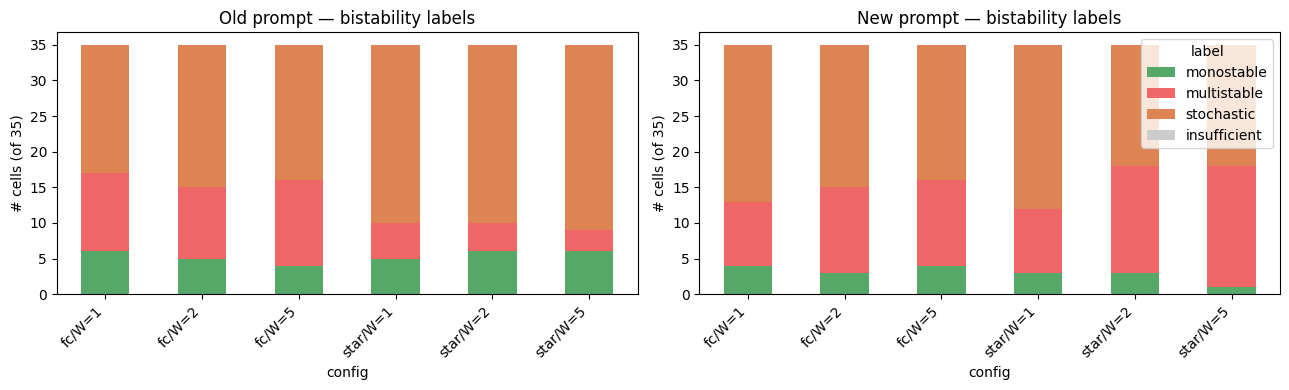

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lab_order = ['monostable','multistable','stochastic','insufficient']
for ax, ds in zip(axes, DS_ORDER):
    ct = (bist[bist.ds==ds].groupby(['config','label']).size()
          .unstack(fill_value=0).reindex(index=CONFIG_ORDER, columns=lab_order, fill_value=0))
    ct.plot(kind='bar', stacked=True, ax=ax, legend=(ds=='new'),
            color=['#55A868','#EE6666','#DD8452','#cccccc'])
    ax.set_title(f'{DS_LABEL[ds]} — bistability labels'); ax.set_ylabel('# cells (of 35)')
    ax.set_xticklabels(CONFIG_ORDER, rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 6. Summary

One row per metric: mean old, mean new, mean paired Δ (new−old) pooled across configs, and the
**number of the 6 configs** where the paired Wilcoxon is Holm-significant (p<0.05) with the sign of
those significant shifts. This is a compact readout — per-config detail is in the sections above.


In [19]:
def pooled_delta(res):
    return res['delta'].mean()
def sig_count(res):
    s = res[res.p_holm < 0.05]
    if len(s) == 0:
        return '0/%d' % len(res)
    signs = np.sign(s['delta'])
    tag = '+' if (signs > 0).all() else ('-' if (signs < 0).all() else '+/-')
    return '%d/%d (%s)' % (len(s), len(res), tag)

summary_rows = [
    ('Accuracy',                    taskvals, 'accuracy',        acc_res),
    ('Mean rounds',                 taskvals, 'mean_rounds',     rnd_res),
    ('Ceiling-hit frac',            taskvals, 'ceil_frac',       ceil_res),
    ('Dominance D',                 dom,      'D_mean',          dom_res),
    ('Hub capitulation',            dom,      'hub_capitulation',cap_res),
    ('Self-reinf p_sr',             sr,       'p_sr',            psr_res),
    ('Self-reinf slope',            sr,       'mean_slope',      slp_res),
    ('Limit cycle (agent)',         lc,       'p_lc_agent',      lca_res),
    ('Limit cycle (system)',        lc,       'p_lc_system',     lcs_res),
    ('Bistability N_eff',           bist,     'n_eff',           neff_res),
    ("Bistability Cramer's V",      bist,     'cramers_v',       cv_res),
    ('Convergence rate',            bist,     'conv_frac',       conv_res),
]
rows = []
for name, df_, col, res in summary_rows:
    rows.append({
        'metric': name,
        'old_mean': df_[df_.ds=='old'][col].mean(),
        'new_mean': df_[df_.ds=='new'][col].mean(),
        'mean_delta': pooled_delta(res),
        'sig_configs': sig_count(res),
    })
summary = pd.DataFrame(rows)
for c in ['old_mean','new_mean','mean_delta']:
    summary[c] = summary[c].map(lambda x: f'{x:+.4f}' if pd.notna(x) else 'nan')
print(summary.to_string(index=False))

                metric old_mean new_mean mean_delta sig_configs
              Accuracy  +0.3163  +0.2940    -0.0223         0/6
           Mean rounds  +6.8517  +6.0402    -0.8116     3/6 (-)
      Ceiling-hit frac  +0.1462  +0.0730    -0.0731     3/6 (-)
           Dominance D  +0.3753  +0.3628    -0.0125         0/6
      Hub capitulation  +0.1463  +0.1685    +0.0222     4/6 (+)
       Self-reinf p_sr  +0.8298  +0.8323    +0.0026         0/6
      Self-reinf slope  +0.3718  +0.3920    +0.0202     1/6 (+)
   Limit cycle (agent)  +0.0192  +0.0416    +0.0116         0/6
  Limit cycle (system)  +0.0402  +0.0837    +0.0250         0/6
     Bistability N_eff  +2.0398  +2.2020    +0.1621     1/6 (+)
Bistability Cramer's V  +0.3936  +0.3501    -0.0434         0/6
      Convergence rate  +0.8619  +0.9351    +0.0732     3/6 (+)


### Reading guide

- **`sig_configs`** = how many of the 6 configs show a Holm-significant paired shift, with the shared
  sign of those shifts (`+` new higher, `−` new lower, `+/-` mixed). `0/6` = no reliable drift.
- **Confidence-weighted metrics** (Dominance D, Hub capitulation, Self-reinf slope) carry the
  old-data 0-confidence artifact — treat their cross-dataset magnitude with the caveat noted in each
  section; sign-based summaries (p_sr, flag rates) are more robust.
- Interpretation of *"better explainability/interpretability"* is left to the written report cell
  below — the tables state only what was measured.


## 7. Written report

**Scope.** 35 HiddenBench questions × 6 configs, same questions in both datasets. Old = old prompt,
R30 (downsampled); new = more-critical prompt (adds *"Do not change your position simply because
others disagree; only update if you encounter a specific argument you cannot counter"*), R50. Paired
by question within config; Wilcoxon signed-rank, Holm-corrected across the 6 configs; bootstrap 95%
CIs on the mean paired delta. All statements below are as measured.

### What changed reliably

1. **Faster convergence in the fully-connected topology.** Rounds-to-consensus dropped by ~1.0–1.5
   in all three fc configs (Holm-sig: fc/W=1 **, fc/W=2 *, fc/W=5 ***). Ceiling-hitting (reps
   running to T=15) fell by ~8–12 pp in all three fc configs (all ***), i.e. roughly halved. In the
   star the same sign appears but is not significant after correction.

2. **Higher convergence rate, mainly in fc.** The fraction of reps that settle into a *unanimous*
   consensus rose from ≈0.86 (old) to ≈0.94 (new). On the R-independent rate this is significant in
   all three fc configs (all ***, +8–12 pp) but not in the star after Holm (positive, +2–7 pp). (The
   raw *count* of converged reps rises in all 6 but is partly mechanical — R50 vs R30 — so the rate
   is the honest number.) The new prompt makes groups reach unanimity more often, not less.

3. **Hubs capitulate slightly more (confidence-weighted).** Hub capitulation rose in fc/W=1 (**),
   fc/W=2 (*) and star/W={2,5} (**/*). Small magnitude (~+0.02–0.04). *Caveat:* this metric is
   confidence-weighted and the old data carries 0-confidence votes, so part of the shift may reflect
   the scale artifact rather than behaviour.

### What did not change

4. **Accuracy: no reliable drift.** 0/6 configs significant; pooled delta −0.022 (new marginally
   lower), every per-config CI straddles 0. The more critical prompt did **not** measurably change
   HiddenBench correctness in either direction.

5. **Dominance D: no reliable drift** (0/6). Level differences by topology persist as before
   (star D≈0.5–0.6 ≫ fc D≈0.16–0.19). Emergent-excess z and flagged-fraction (fc only) trend upward
   but are not significant after correction.

6. **Self-reinforcement: essentially unchanged.** Prevalence p_sr 0/6 (≈0.83 both). Mean confidence
   slope is nominally higher in new but significant in only 1/6 (fc/W=2). *Same confidence caveat as
   above applies to slope magnitude.*

7. **Limit cycles: no significant drift** (agent 0/6, system 0/6). Raw pooled rates are higher in new
   (agent 0.019→0.042, system 0.040→0.084) but candidate counts per config are small (n_pairs 4–24),
   so these are noisy and do not survive correction. Not evidence of more cycling.

### Bistability — the "less noisy / more consistent" question

8. **More reliable convergence, but *not* fewer distinct attractors.** N_eff (distinct consensus
   attractors) is nominally *higher* in new (pooled +0.16), significant in 1/6 (star/W=5 ***).
   So the new prompt does **not** collapse groups onto a single answer more often; if anything reps
   spread across slightly more consensus states.

9. **Label mix shifts toward "multistable" — but read this as a power effect, not stronger basin
   determinism.** New has more multistable (45→74) and fewer stochastic (133→118) and monostable
   (32→18) cells. Multistable requires a *significant* basin test (p_basin<α); the higher convergence
   rate (more converged reps) gives more power to detect basin structure, flipping stochastic→
   multistable. Consistently, the per-cell effect size **Cramér's V actually trends slightly *down***
   (pooled −0.043; ns after Holm, though several fc CIs exclude 0). Initial-condition→attractor
   coupling is not stronger under the new prompt — the label shift is driven by power, not by a
   larger basin effect.

### Bottom line

The new, more critical prompt makes the system **converge more often and faster (fc)** with
**unchanged accuracy**. It does **not** reduce multistability or noise in outcome selection — N_eff
is flat-to-slightly-higher and basin determinism (Cramér's V) is flat-to-slightly-lower. The
cleanest interpretability gains are dynamical (faster, more complete convergence; fewer runaway
ceiling-hitting trajectories) rather than a reduction in attractor multiplicity. Two data-hygiene
improvements are also confirmed in the new run: **no 0-confidence votes** (1183→0) and **no stray
out-of-option votes** (1→0). Confidence-weighted comparisons (dominance capitulation, SR slope)
should be read with the old-data 0-confidence caveat in mind.
